# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
Link Dataset : https://www.kaggle.com/datasets/nancyalaswad90/lung-cancer

  Dataset yang digunakan adalah "Survey Lung Cancer" yang berisi data survei pasien untuk memprediksi kemungkinan kanker paru-paru berdasarkan berbagai atribut.

**Atribut pada Dataset:**
* **GENDER:** Jenis kelamin pasien (M/F)
* **AGE:** Usia pasien
* **SMOKING:** Apakah pasien merokok (2=Ya, 1=Tidak)
* **YELLOW_FINGERS:** Apakah pasien memiliki jari kuning (2=Ya, 1=Tidak)
* **ANXIETY:** Apakah pasien memiliki kecemasan (2=Ya, 1=Tidak)
* **PEER_PRESSURE:** Apakah pasien mengalami tekanan dari rekan sebaya (2=Ya, 1=Tidak)
* **CHRONIC DISEASE:** Apakah pasien memiliki penyakit kronis (2=Ya, 1=Tidak)
* **FATIGUE:** Apakah pasien sering merasa lelah (2=Ya, 1=Tidak)
* **ALLERGY:** Apakah pasien memiliki alergi (2=Ya, 1=Tidak)
* **WHEEZING:** Apakah pasien mengalami mengi (2=Ya, 1=Tidak)
* **ALCOHOL CONSUMING:** Apakah pasien mengonsumsi alkohol (2=Ya, 1=Tidak)
* **COUGHING:** Apakah pasien sering batuk (2=Ya, 1=Tidak)
* **SHORTNESS OF BREATH:** Apakah pasien mengalami sesak napas (2=Ya, 1=Tidak)
* **SWALLOWING DIFFICULTY:** Apakah pasien mengalami kesulitan menelan (2=Ya, 1=Tidak)
* **CHEST PAIN:** Apakah pasien mengalami nyeri dada (2=Ya, 1=Tidak)
* **LUNG_CANCER:** **(Target)** Apakah pasien didiagnosis kanker paru-paru (YES/NO)

Tujuan dari proyek ini adalah membangun sistem machine learning yang dapat memprediksi `LUNG_CANCER` berdasarkan fitur-fitur yang ada.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [13]:
# Mengimpor library yang diperlukan untuk analisis dan pemrosesan data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# Mengatur agar pandas menampilkan semua kolom dari dataframe
pd.set_option('display.max_columns', None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
# Memuat dataset dari file CSV ke dalam DataFrame pandas
df = pd.read_csv('/content/survey_lung_cancer.csv')

# Menampilkan 5 baris pertama untuk melihat sampel data
print("Lima baris pertama dari dataset:")
df.head()

Lima baris pertama dari dataset:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [15]:
# Menampilkan informasi ringkas tentang dataset, termasuk tipe data dan nilai non-null
print("Informasi Dataset:")
df.info()

print("\n======================================================\n")

# Menampilkan statistik deskriptif untuk kolom-kolom numerik
print("Deskripsi Statistik Dataset:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [16]:
# Memeriksa jumlah nilai yang hilang (missing values) di setiap kolom
print("Jumlah nilai yang hilang di setiap kolom:")
df.isnull().sum()

Jumlah nilai yang hilang di setiap kolom:


,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


Distribusi Kelas pada Kolom Target (sebelum diubah):
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


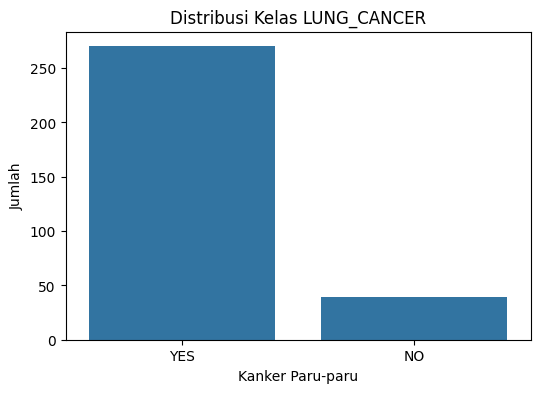

In [17]:
# Menganalisis distribusi kelas pada kolom target 'LUNG_CANCER'
print("Distribusi Kelas pada Kolom Target (sebelum diubah):")
print(df['LUNG_CANCER'].value_counts())

# Membuat visualisasi distribusi kelas menggunakan countplot dari seaborn
plt.figure(figsize=(6, 4))
sns.countplot(x='LUNG_CANCER', data=df)
plt.title('Distribusi Kelas LUNG_CANCER')
plt.xlabel('Kanker Paru-paru')
plt.ylabel('Jumlah')
plt.show()

<ipython-input-18-4079248093>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr['GENDER'] = df_corr['GENDER'].replace({'M': 1, 'F': 0})
<ipython-input-18-4079248093>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr['LUNG_CANCER'] = df_corr['LUNG_CANCER'].replace({'YES': 1, 'NO': 0})


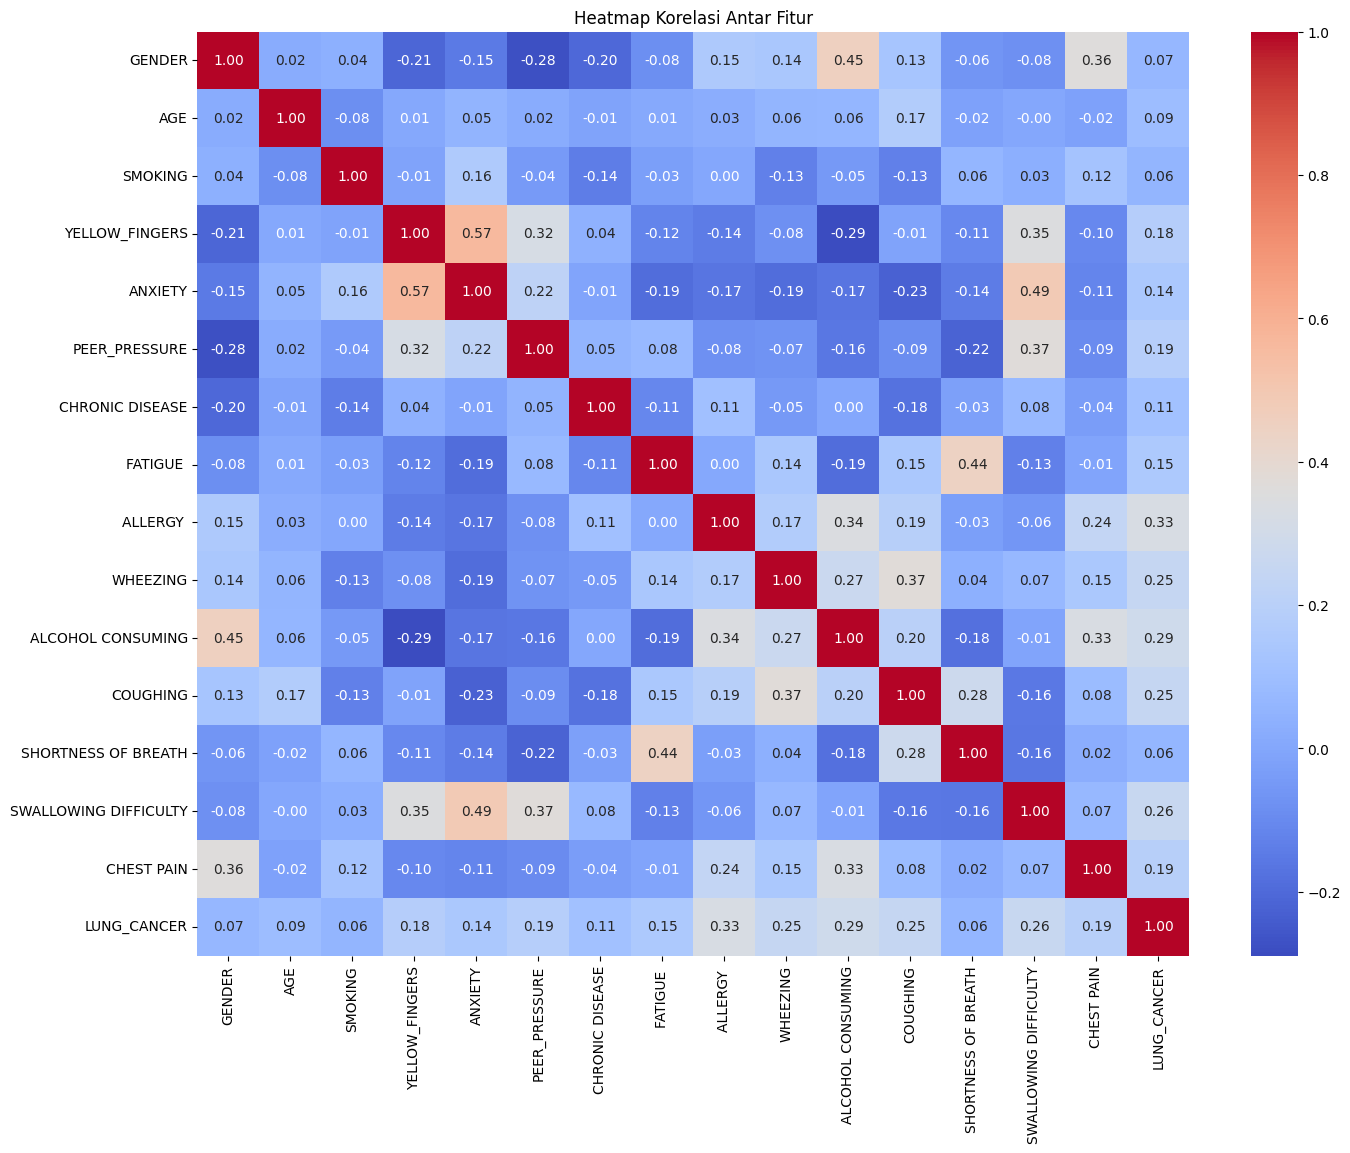

In [18]:
# Mengubah GENDER dan LUNG_CANCER menjadi numerik sementara untuk analisis korelasi
df_corr = df.copy()
df_corr['GENDER'] = df_corr['GENDER'].replace({'M': 1, 'F': 0})
df_corr['LUNG_CANCER'] = df_corr['LUNG_CANCER'].replace({'YES': 1, 'NO': 0})

# Menghitung matriks korelasi
plt.figure(figsize=(16, 12))
correlation_matrix = df_corr.corr()

# Membuat heatmap untuk memvisualisasikan korelasi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
# Mengubah kolom 'GENDER' dari kategorikal (M/F) menjadi numerik (1/0)
df['GENDER'] = df['GENDER'].replace({'M': 1, 'F': 0})

# Mengubah kolom target 'LUNG_CANCER' dari kategorikal (YES/NO) menjadi numerik (1/0)
df['LUNG_CANCER'] = df['LUNG_CANCER'].replace({'YES': 1, 'NO': 0})

print("Tipe data setelah encoding:")
df.dtypes

Tipe data setelah encoding:


<ipython-input-19-3906546240>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GENDER'] = df['GENDER'].replace({'M': 1, 'F': 0})
<ipython-input-19-3906546240>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LUNG_CANCER'] = df['LUNG_CANCER'].replace({'YES': 1, 'NO': 0})


,0
GENDER,int64
AGE,int64
SMOKING,int64
YELLOW_FINGERS,int64
ANXIETY,int64
PEER_PRESSURE,int64
CHRONIC DISEASE,int64
FATIGUE,int64
ALLERGY,int64
WHEEZING,int64


In [20]:
# Memisahkan fitur (variabel independen) dan target (variabel dependen)
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Membagi dataset menjadi data latih (80%) dan data uji (20%)
# stratify=y digunakan untuk memastikan proporsi kelas target sama di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensi data latih (X_train):", X_train.shape)
print("Dimensi data uji (X_test):", X_test.shape)

Dimensi data latih (X_train): (247, 15)
Dimensi data uji (X_test): (62, 15)


In [21]:
# Inisialisasi MinMaxScaler untuk mengubah skala fitur ke rentang [0, 1]
scaler = MinMaxScaler()

# Melakukan normalisasi pada data latih dan data uji
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengubah hasil scaling kembali menjadi DataFrame agar mudah dibaca
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data Latih (X_train) Setelah Normalisasi (5 baris pertama):")
X_train_scaled.head()

Data Latih (X_train) Setelah Normalisasi (5 baris pertama):


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0.0,0.469388,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
1,0.0,0.530612,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.714286,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.489796,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
4,1.0,0.265306,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


In [22]:
# Membuat direktori 'preprocessing' untuk menyimpan file hasil olahan
if not os.path.exists('preprocessing'):
    os.makedirs('preprocessing')

# Menggabungkan kembali fitur dan target yang sudah diproses
train_data = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

# Menyimpan data latih dan uji yang sudah bersih ke file CSV
train_data.to_csv('preprocessing/lung_cancer_train_preprocessed.csv', index=False)
test_data.to_csv('preprocessing/lung_cancer_test_preprocessed.csv', index=False)

# Menyimpan objek scaler untuk digunakan pada data baru saat inferensi/prediksi
joblib.dump(scaler, 'preprocessing/scaler.joblib')

print("File hasil preprocessing telah berhasil disimpan di dalam folder 'preprocessing'.")
print("File yang disimpan:")
print("- lung_cancer_train_preprocessed.csv")
print("- lung_cancer_test_preprocessed.csv")
print("- scaler.joblib")

File hasil preprocessing telah berhasil disimpan di dalam folder 'preprocessing'.
File yang disimpan:
- lung_cancer_train_preprocessed.csv
- lung_cancer_test_preprocessed.csv
- scaler.joblib
